# Correlation Skew as a Signal for Quanto Hedge Fragility
## ASML ADR / ASML Amsterdam / EUR-USD — Implied Correlation Analysis

**Research question:** Does correlation skew in vanilla option markets identify periods where ATM-based quanto hedges become more fragile?

---

### Key Identities

**ADR variance decomposition** (no-arb, log-price space):

$$\sigma_\text{ADR}^2 = \sigma_\text{loc}^2 + \sigma_\text{FX}^2 + 2\,\rho\,\sigma_\text{loc}\,\sigma_\text{FX}$$

**Implied correlation** (backed out from market IVs):

$$\hat{\rho} = \frac{\sigma_\text{ADR}^2 - \sigma_\text{loc}^2 - \sigma_\text{FX}^2}{2\,\sigma_\text{loc}\,\sigma_\text{FX}}, \quad \hat{\rho} \in [-1, 1]$$

**Correlation skew** (put-strike vs call-strike implied rho):

$$\text{corr\_skew} = \hat{\rho}_\text{put} - \hat{\rho}_\text{call}$$

**Cross-term** (covariance contribution to ADR variance, in pp²):

$$\text{CT} = 2\,\hat{\rho}\,\sigma_\text{loc}\,\sigma_\text{FX}$$

**Hedge fragility** (forward-looking magnitude of covariance drift):

$$\text{fragility}_{h} = |\Delta \hat{\rho}_{t+h}| \quad \text{and} \quad |\Delta \text{CT}_{t+h}|$$

---

*Data: Bloomberg implied vols from ASML NA (ADR), ASML NA (local Amsterdam), EURUSD — 1M / 3M / 1Y tenors, 2014–2024*

## Section 2 — Load and Inspect Data

In [30]:
import pathlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT      = pathlib.Path("..").resolve()
DATA_PATH = ROOT / "data" / "processed" / "derived_dataset.csv"

# ── Plot defaults ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":      130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "font.size":       10,
})

# ── Load ───────────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print(f"Shape : {df.shape}")
print(f"Dates : {df['date'].min().date()} → {df['date'].max().date()}  ({len(df)} rows)")
print(f"Cols  : {df.shape[1]}")

# ── Core columns of interest ───────────────────────────────────────────────────
CORE = [
    "rho_1m", "rho_put_1m", "rho_call_1m", "corr_skew_1m",
    "cross_term_1m",
    "rho_drift_1d", "rho_drift_5d", "rho_drift_20d",
    "cross_term_drift_1d", "cross_term_drift_5d", "cross_term_drift_20d",
    "adr_skew_1m", "loc_skew_1m", "fx_RR_1M",
]

missing = [c for c in CORE if c not in df.columns]
if missing:
    print(f"\n⚠️  Missing columns: {missing}")
else:
    print(f"\n✅ All {len(CORE)} core columns present")

# ── Summary stats ──────────────────────────────────────────────────────────────
summary_cols = ["rho_1m", "rho_put_1m", "rho_call_1m", "corr_skew_1m"]
display(df[summary_cols].describe().round(4))

Shape : (2491, 43)
Dates : 2016-01-04 → 2025-12-31  (2491 rows)
Cols  : 43

✅ All 14 core columns present


,rho_1m,rho_put_1m,rho_call_1m,corr_skew_1m
count,2491.0000,2491.0000,2491.0000,2491.0000
mean,0.1044,0.0079,0.0324,-0.0245
std,0.3143,0.4154,0.4107,0.3439
min,-1.0000,-1.0000,-1.0000,-1.7896
25%,-0.0902,-0.2385,-0.2114,-0.1713
50%,0.1049,0.0151,0.0313,-0.0084
75%,0.2913,0.2475,0.2669,0.1258
max,1.0000,1.0000,1.0000,2.0000


## Section 3 — Core Time Series

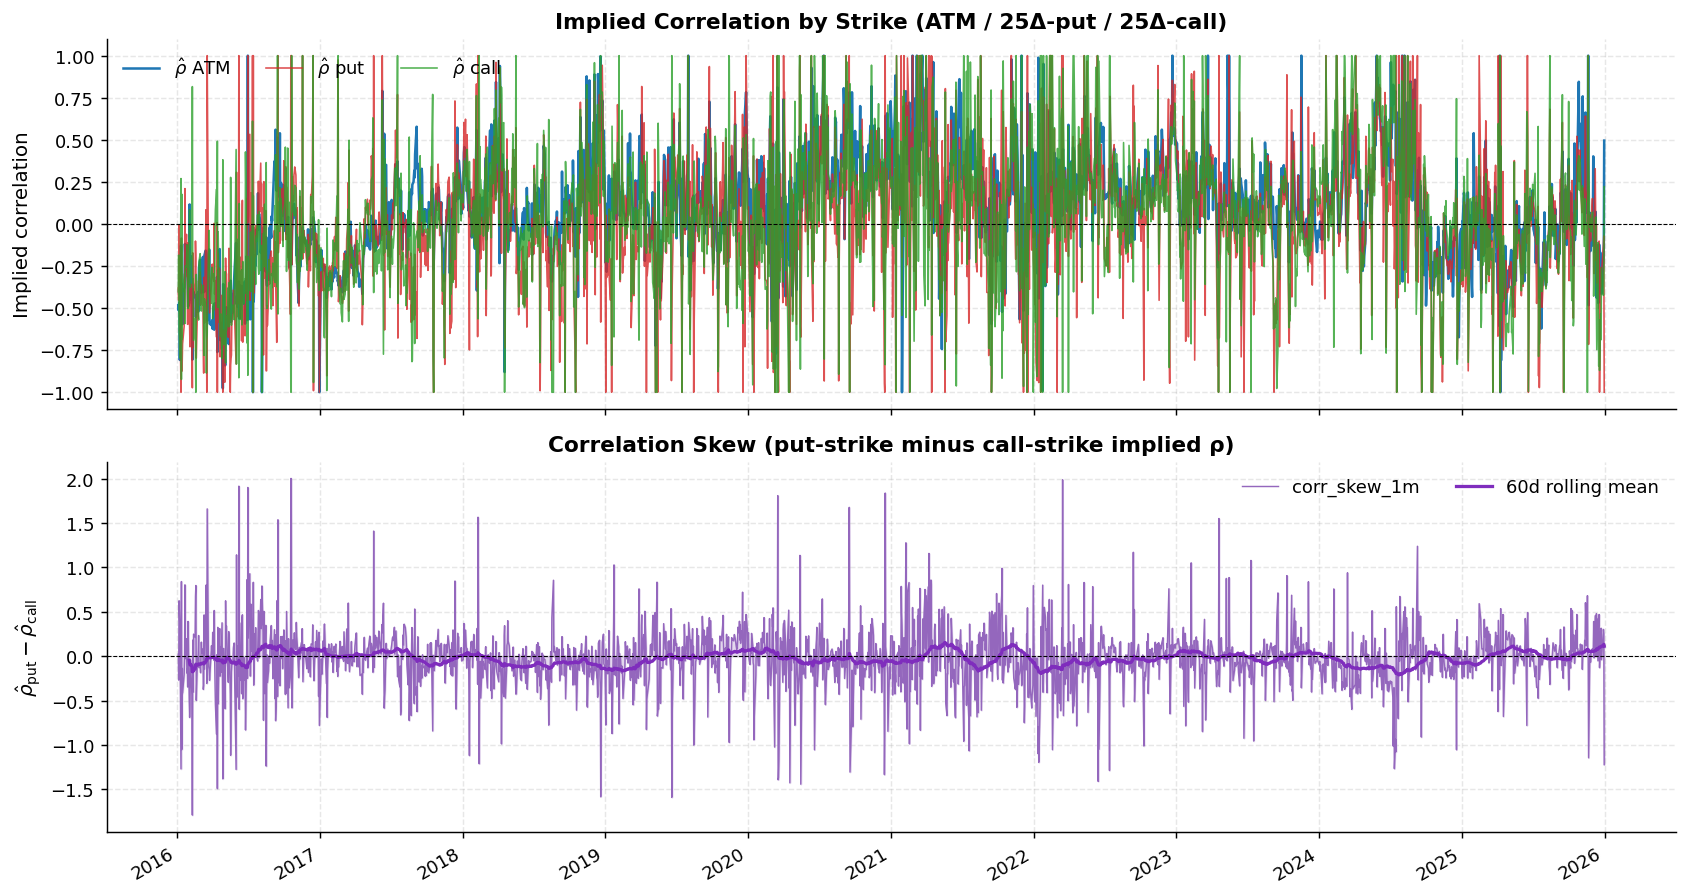

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# ── Plot 1: ATM rho vs put-strike rho vs call-strike rho ──────────────────────
ax = axes[0]
ax.plot(df["date"], df["rho_1m"],      label=r"$\hat{\rho}$ ATM",  lw=1.4, color="#1f77b4")
ax.plot(df["date"], df["rho_put_1m"],  label=r"$\hat{\rho}$ put",  lw=0.9, color="#d62728", alpha=0.8)
ax.plot(df["date"], df["rho_call_1m"], label=r"$\hat{\rho}$ call", lw=0.9, color="#2ca02c", alpha=0.8)
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_ylabel("Implied correlation")
ax.set_title("Implied Correlation by Strike (ATM / 25Δ-put / 25Δ-call)", fontweight="bold")
ax.legend(frameon=False, ncol=3)

# ── Plot 2: Correlation skew + 60-day rolling mean ────────────────────────────
ax = axes[1]
roll60 = df["corr_skew_1m"].rolling(60, min_periods=20).mean()
ax.fill_between(df["date"], df["corr_skew_1m"], alpha=0.25, color="#9467bd")
ax.plot(df["date"], df["corr_skew_1m"], lw=0.8, color="#9467bd", label="corr_skew_1m")
ax.plot(df["date"], roll60, lw=1.8, color="#7f2dbd", label="60d rolling mean")
ax.axhline(0, color="k", lw=0.6, ls="--")
ax.set_ylabel(r"$\hat{\rho}_\mathrm{put} - \hat{\rho}_\mathrm{call}$")
ax.set_title("Correlation Skew (put-strike minus call-strike implied ρ)", fontweight="bold")
ax.legend(frameon=False, ncol=2)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Section 4 — Define Hedge Fragility

We measure **forward-looking instability** of the ATM quanto hedge using two targets:

- **|Δρ|**: absolute change in ATM implied correlation over horizon *h*
- **|ΔCT|**: absolute change in the cross-term $2\hat{\rho}\,\sigma_\text{loc}\,\sigma_\text{FX}$ over horizon *h*

Three horizons: 1-day, 5-day, 20-day.

In [32]:
HORIZONS = ["1d", "5d", "20d"]

# Construct absolute-value fragility columns from signed drift columns
for h in HORIZONS:
    rho_col = f"rho_drift_{h}"
    ct_col  = f"cross_term_drift_{h}"
    if rho_col in df.columns:
        df[f"abs_rho_drift_{h}"]   = df[rho_col].abs()
    if ct_col in df.columns:
        df[f"abs_cross_term_drift_{h}"] = df[ct_col].abs()

frag_cols = [f"abs_rho_drift_{h}" for h in HORIZONS] + \
            [f"abs_cross_term_drift_{h}" for h in HORIZONS]

missing_frag = [c for c in frag_cols if c not in df.columns]
if missing_frag:
    print(f"⚠️  Could not construct: {missing_frag}")
else:
    print("✅ All fragility columns constructed")

display(df[frag_cols].describe().round(4))

✅ All fragility columns constructed


,abs_rho_drift_1d,abs_rho_drift_5d,abs_rho_drift_20d,abs_cross_term_drift_1d,abs_cross_term_drift_5d,abs_cross_term_drift_20d
count,2490.0000,2486.0000,2471.0000,2490.0000,2486.0000,2471.0000
mean,0.1737,0.2187,0.2629,86.5956,104.8204,126.6162
std,0.1948,0.2023,0.2266,153.3860,139.8350,143.3677
min,0.0000,0.0000,0.0001,0.1746,0.0193,0.0493
25%,0.0505,0.0744,0.0927,20.6140,31.6426,38.5299
50%,0.1161,0.1656,0.2058,47.7104,67.8552,91.9754
75%,0.2250,0.2971,0.3735,100.5257,131.5154,164.4581
max,2.0000,1.5924,1.4940,2856.6621,2116.9888,1573.7597


## Section 5 — Signed Decile Analysis (Main Result)

Bin observations by **signed** `corr_skew_1m` into ten equal-count deciles (D01 = most negative skew, D10 = most positive skew). Report mean fragility per decile, normalised by D05 (central decile = 1.00).

**Hypothesis:** Extreme deciles (D01 and D10) should show elevated fragility — a "bat-shaped" U-pattern.

In [33]:
DECILE_LABELS = [f"D{i:02d}" for i in range(1, 11)]

# Z-score corr_skew_1m (cross-sectional, to handle level shifts)
mu  = df["corr_skew_1m"].mean()
std = df["corr_skew_1m"].std()
df["corr_skew_z"] = (df["corr_skew_1m"] - mu) / std

# Bin into 10 equal-count deciles by signed skew
df["skew_decile"] = pd.qcut(
    df["corr_skew_z"], q=10, labels=DECILE_LABELS, duplicates="drop"
)


def decile_fragility_table(target_prefix: str, label: str) -> pd.DataFrame:
    """Return mean fragility per decile at 1d/5d/20d, with ratio-to-D05."""
    rows = []
    grp  = df.groupby("skew_decile", observed=True)
    for h in HORIZONS:
        col  = f"abs_{target_prefix}_drift_{h}"
        means = grp[col].mean()
        base  = means.get("D05", np.nan)
        row   = {"Horizon": h, "Metric": label}
        for d in DECILE_LABELS:
            v = means.get(d, np.nan)
            row[d] = f"{v:.4f}  ({v/base:.2f}×)" if not np.isnan(v) and base > 0 else "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index(["Metric", "Horizon"])


print("═" * 80)
print("  |Δρ| by Signed Decile  (value + ÷D05 ratio)")
print("═" * 80)
tbl_rho = decile_fragility_table("rho", "|Δρ|")
display(tbl_rho)

print("\n")
print("═" * 80)
print("  |ΔCT| by Signed Decile  (value + ÷D05 ratio)")
print("═" * 80)
tbl_ct = decile_fragility_table("cross_term", "|ΔCT|")
display(tbl_ct)

════════════════════════════════════════════════════════════════════════════════
  |Δρ| by Signed Decile  (value + ÷D05 ratio)
════════════════════════════════════════════════════════════════════════════════


D01              D02              D03  \
Metric Horizon                                                      
|Δρ|   1d       0.2070  (1.51×)  0.1860  (1.36×)  0.1667  (1.22×)   
       5d       0.2394  (1.22×)  0.2369  (1.21×)  0.2176  (1.11×)   
       20d      0.2647  (1.17×)  0.2873  (1.27×)  0.2466  (1.09×)   

                            D04              D05              D06  \
Metric Horizon                                                      
|Δρ|   1d       0.1398  (1.02×)  0.1371  (1.00×)  0.1938  (1.41×)   
       5d       0.1885  (0.96×)  0.1965  (1.00×)  0.2429  (1.24×)   
       20d      0.2312  (1.02×)  0.2264  (1.00×)  0.2968  (1.31×)   

                            D07              D08              D09  \
Metric Horizon                                                      
|Δρ|   1d       0.1363  (0.99×)  0.1606  (1.17×)  0.1859  (1.36×)   
       5d       0.1796  (0.91×)  0.2114  (1.08×)  0.2216  (1.13×)   
       20d      0.2282  (1.01×)  0.2547  (1.13×)  0.2554  (1.13×)   

                            D10  
Metric Horizon                   
|Δρ|   1d       0.2240  (1.63×)  
       5d       0.2525  (1.28×)  
       20d      0.3394  (1.50×)



════════════════════════════════════════════════════════════════════════════════
  |ΔCT| by Signed Decile  (value + ÷D05 ratio)
════════════════════════════════════════════════════════════════════════════════


D01                D02                D03  \
Metric Horizon                                                            
|ΔCT|  1d       112.3437  (1.69×)   88.1953  (1.33×)   81.4259  (1.22×)   
       5d       131.8057  (1.35×)  105.9989  (1.09×)  101.0986  (1.04×)   
       20d      139.7477  (1.31×)  130.4522  (1.22×)  107.9089  (1.01×)   

                              D04                D05                D06  \
Metric Horizon                                                            
|ΔCT|  1d        71.3312  (1.07×)   66.4905  (1.00×)  104.0911  (1.57×)   
       5d        93.5698  (0.96×)   97.3758  (1.00×)  121.0707  (1.24×)   
       20d      117.0188  (1.10×)  106.5441  (1.00×)  143.1528  (1.34×)   

                              D07                D08                D09  \
Metric Horizon                                                            
|ΔCT|  1d        63.2767  (0.95×)   70.8193  (1.07×)   92.5994  (1.39×)   
       5d        83.4210  (0.86×)   93.8855  (0.96×)  104.2519  (1.07×)   
       20d      115.2395  (1.08×)  128.8639  (1.21×)  115.2502  (1.08×)   

                              D10  
Metric Horizon                     
|ΔCT|  1d       115.3827  (1.74×)  
       5d       115.7359  (1.19×)  
       20d      162.7881  (1.53×)

## Section 6 — Bat-Shaped Ratio Plot

Visualise the U-shaped ("bat-shaped") fragility pattern: mean |Δρ| and |ΔCT| per signed decile, normalised so that D05 = 1.00. One panel per horizon.

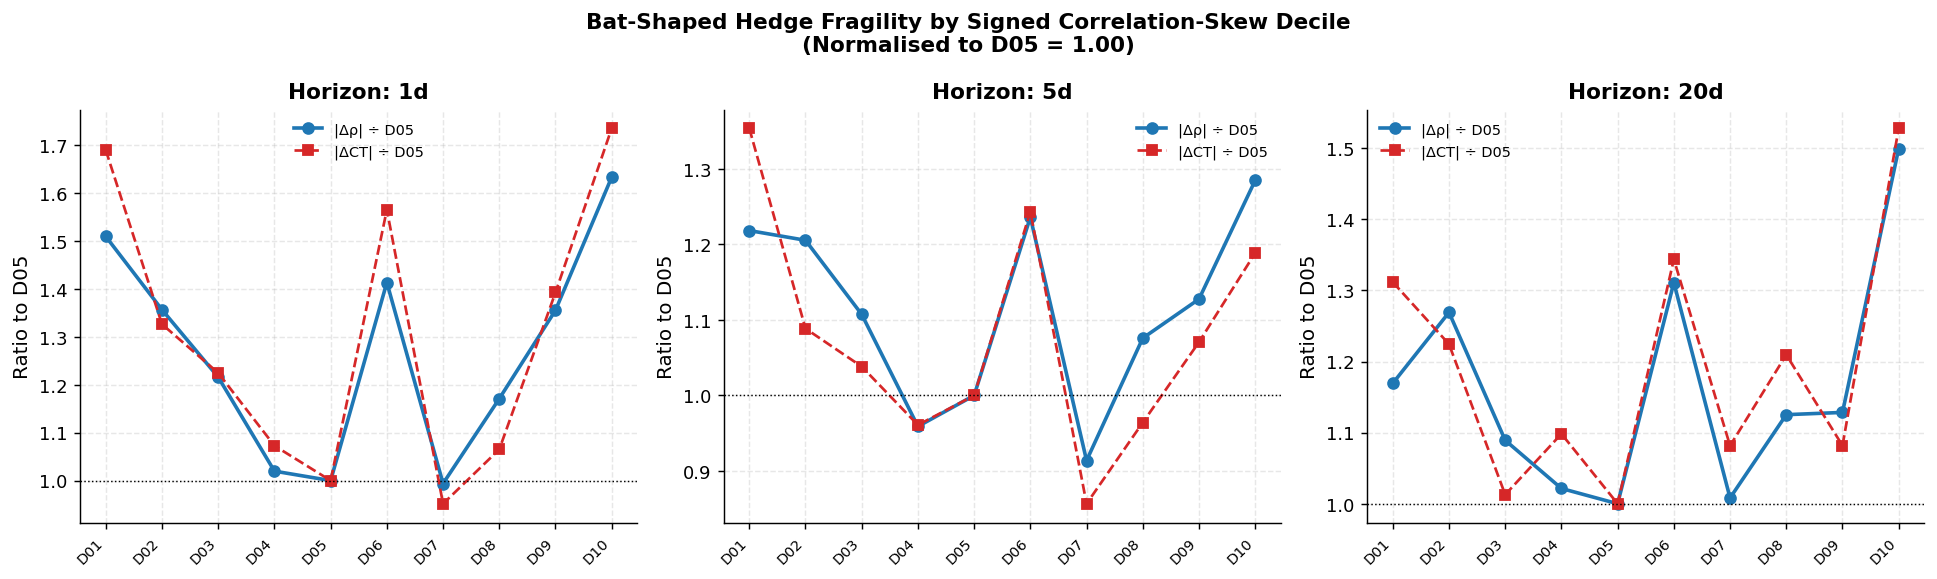

In [34]:
grp = df.groupby("skew_decile", observed=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
fig.suptitle("Bat-Shaped Hedge Fragility by Signed Correlation-Skew Decile\n"
             "(Normalised to D05 = 1.00)", fontweight="bold", fontsize=12)

for ax, h in zip(axes, HORIZONS):
    rho_means = grp[f"abs_rho_drift_{h}"].mean()
    ct_means  = grp[f"abs_cross_term_drift_{h}"].mean()

    base_rho = rho_means.get("D05", np.nan)
    base_ct  = ct_means.get("D05", np.nan)

    rho_ratio = rho_means / base_rho
    ct_ratio  = ct_means  / base_ct

    x = range(len(DECILE_LABELS))
    ax.plot(x, rho_ratio.values, "o-", color="#1f77b4", lw=2,   ms=6, label="|Δρ| ÷ D05")
    ax.plot(x, ct_ratio.values,  "s--", color="#d62728", lw=1.5, ms=5, label="|ΔCT| ÷ D05")
    ax.axhline(1.0, color="k", lw=0.8, ls=":")
    ax.set_xticks(list(x))
    ax.set_xticklabels(DECILE_LABELS, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Horizon: {h}", fontweight="bold")
    ax.set_ylabel("Ratio to D05")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Section 7 — Magnitude Decile Analysis

Bin by **absolute** `|corr_skew_1m|` (z-scored) into ten equal-count magnitude deciles M01–M10 (M01 = smallest absolute skew, M10 = largest). A monotone increase confirms that *how extreme* the skew is matters, regardless of sign.

════════════════════════════════════════════════════════════════════════════════
  |Δρ| by Magnitude Decile  (value + ÷M01 ratio)
════════════════════════════════════════════════════════════════════════════════


M01              M02              M03  \
Metric Horizon                                                      
|Δρ|   1d       0.1871  (1.00×)  0.1305  (0.70×)  0.1329  (0.71×)   
       5d       0.2464  (1.00×)  0.1825  (0.74×)  0.1773  (0.72×)   
       20d      0.2561  (1.00×)  0.2585  (1.01×)  0.2330  (0.91×)   

                            M04              M05              M06  \
Metric Horizon                                                      
|Δρ|   1d       0.1520  (0.81×)  0.1620  (0.87×)  0.1613  (0.86×)   
       5d       0.1966  (0.80×)  0.2171  (0.88×)  0.2090  (0.85×)   
       20d      0.2334  (0.91×)  0.2745  (1.07×)  0.2259  (0.88×)   

                            M07              M08              M09  \
Metric Horizon                                                      
|Δρ|   1d       0.1711  (0.91×)  0.1999  (1.07×)  0.2034  (1.09×)   
       5d       0.2182  (0.89×)  0.2370  (0.96×)  0.2430  (0.99×)   
       20d      0.2527  (0.99×)  0.2935  (1.15×)  0.3035  (1.18×)   

                            M10  
Metric Horizon                   
|Δρ|   1d       0.2294  (1.23×)  
       5d       0.2510  (1.02×)  
       20d      0.2995  (1.17×)



════════════════════════════════════════════════════════════════════════════════
  |ΔCT| by Magnitude Decile  (value + ÷M01 ratio)
════════════════════════════════════════════════════════════════════════════════


M01                M02                M03  \
Metric Horizon                                                            
|ΔCT|  1d       104.2897  (1.00×)   61.9142  (0.59×)   60.2213  (0.58×)   
       5d       130.4482  (1.00×)   83.6524  (0.64×)   83.3738  (0.64×)   
       20d      128.3818  (1.00×)  119.4481  (0.93×)  112.0768  (0.87×)   

                              M04                M05                M06  \
Metric Horizon                                                            
|ΔCT|  1d        73.0949  (0.70×)   72.0834  (0.69×)   79.8176  (0.77×)   
       5d        92.9302  (0.71×)   93.9857  (0.72×)  100.4930  (0.77×)   
       20d      119.1894  (0.93×)  128.3499  (1.00×)  109.1594  (0.85×)   

                              M07                M08                M09  \
Metric Horizon                                                            
|ΔCT|  1d        76.4426  (0.73×)   98.1735  (0.94×)  104.6453  (1.00×)   
       5d        97.4591  (0.75×)  109.0739  (0.84×)  115.4915  (0.89×)   
       20d      106.2221  (0.83×)  138.6858  (1.08×)  144.6039  (1.13×)   

                              M10  
Metric Horizon                     
|ΔCT|  1d       129.4180  (1.24×)  
       5d       134.8910  (1.03×)  
       20d      159.4949  (1.24×)

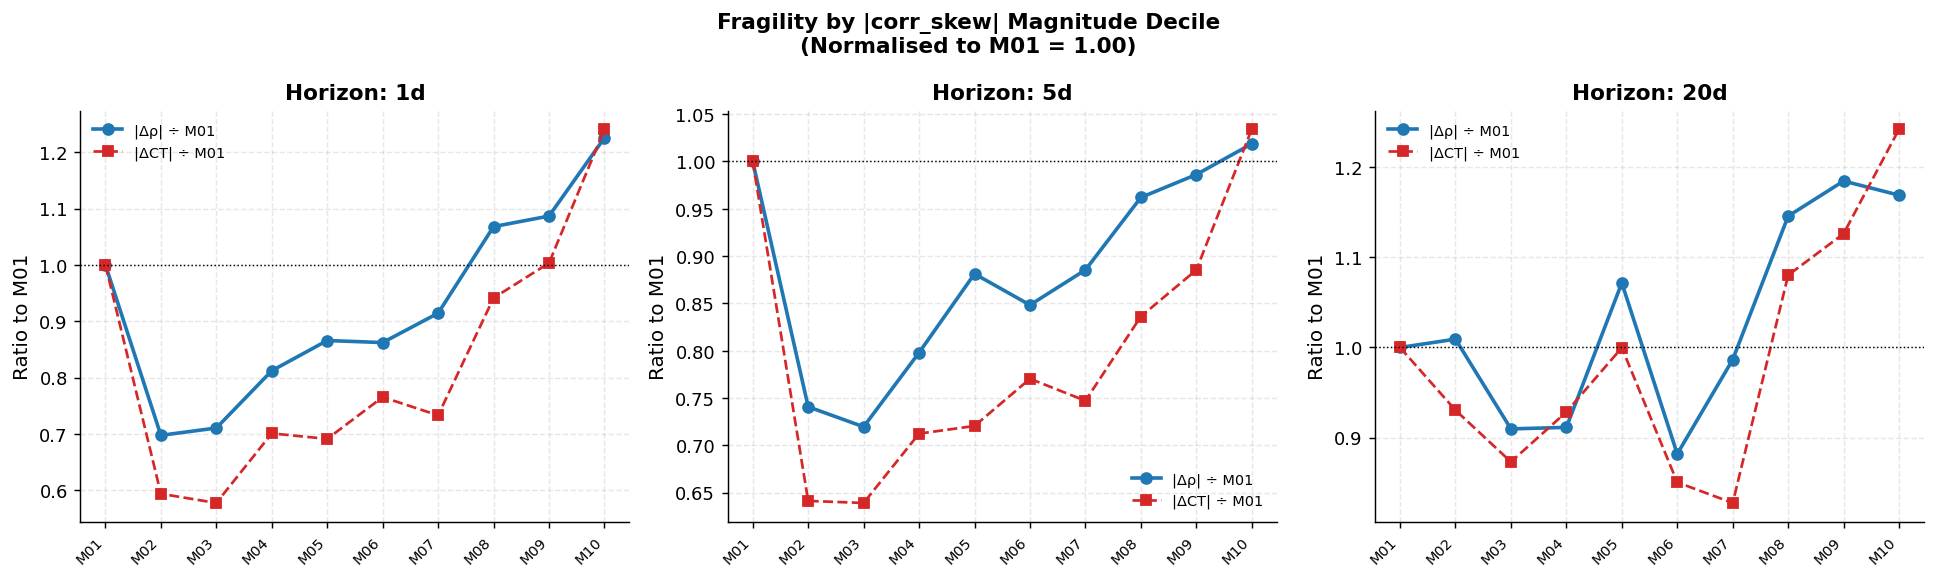

In [35]:
MAG_LABELS = [f"M{i:02d}" for i in range(1, 11)]

# Bin by absolute z-scored skew
df["abs_skew_z"]    = df["corr_skew_z"].abs()
df["mag_decile"]    = pd.qcut(
    df["abs_skew_z"], q=10, labels=MAG_LABELS, duplicates="drop"
)

mgrp = df.groupby("mag_decile", observed=True)


def mag_decile_table(target_prefix: str, label: str) -> pd.DataFrame:
    """Return mean fragility per magnitude decile at 1d/5d/20d, with ratio-to-M01."""
    rows = []
    for h in HORIZONS:
        col   = f"abs_{target_prefix}_drift_{h}"
        means = mgrp[col].mean()
        base  = means.get("M01", np.nan)
        row   = {"Horizon": h, "Metric": label}
        for m in MAG_LABELS:
            v = means.get(m, np.nan)
            row[m] = f"{v:.4f}  ({v/base:.2f}×)" if not np.isnan(v) and base > 0 else "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index(["Metric", "Horizon"])


print("═" * 80)
print("  |Δρ| by Magnitude Decile  (value + ÷M01 ratio)")
print("═" * 80)
mtbl_rho = mag_decile_table("rho", "|Δρ|")
display(mtbl_rho)

print("\n")
print("═" * 80)
print("  |ΔCT| by Magnitude Decile  (value + ÷M01 ratio)")
print("═" * 80)
mtbl_ct = mag_decile_table("cross_term", "|ΔCT|")
display(mtbl_ct)

# ── Magnitude line chart ───────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
fig2.suptitle("Fragility by |corr_skew| Magnitude Decile\n"
              "(Normalised to M01 = 1.00)", fontweight="bold", fontsize=12)

for ax, h in zip(axes2, HORIZONS):
    rho_means = mgrp[f"abs_rho_drift_{h}"].mean()
    ct_means  = mgrp[f"abs_cross_term_drift_{h}"].mean()

    base_rho = rho_means.get("M01", np.nan)
    base_ct  = ct_means.get("M01", np.nan)

    rho_ratio = rho_means / base_rho
    ct_ratio  = ct_means  / base_ct

    x = range(len(MAG_LABELS))
    ax.plot(x, rho_ratio.values, "o-",  color="#1f77b4", lw=2,   ms=6, label="|Δρ| ÷ M01")
    ax.plot(x, ct_ratio.values,  "s--", color="#d62728", lw=1.5, ms=5, label="|ΔCT| ÷ M01")
    ax.axhline(1.0, color="k", lw=0.8, ls=":")
    ax.set_xticks(list(x))
    ax.set_xticklabels(MAG_LABELS, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"Horizon: {h}", fontweight="bold")
    ax.set_ylabel("Ratio to M01")
    ax.legend(frameon=False, fontsize=8)

fig2.tight_layout()
plt.show()

## Section 8 — Raw Magnitude Plots

Same decile results without normalisation — actual |Δρ| and |ΔCT| values per decile. 2×3 grid: rows = signed decile / magnitude decile; columns = horizons.

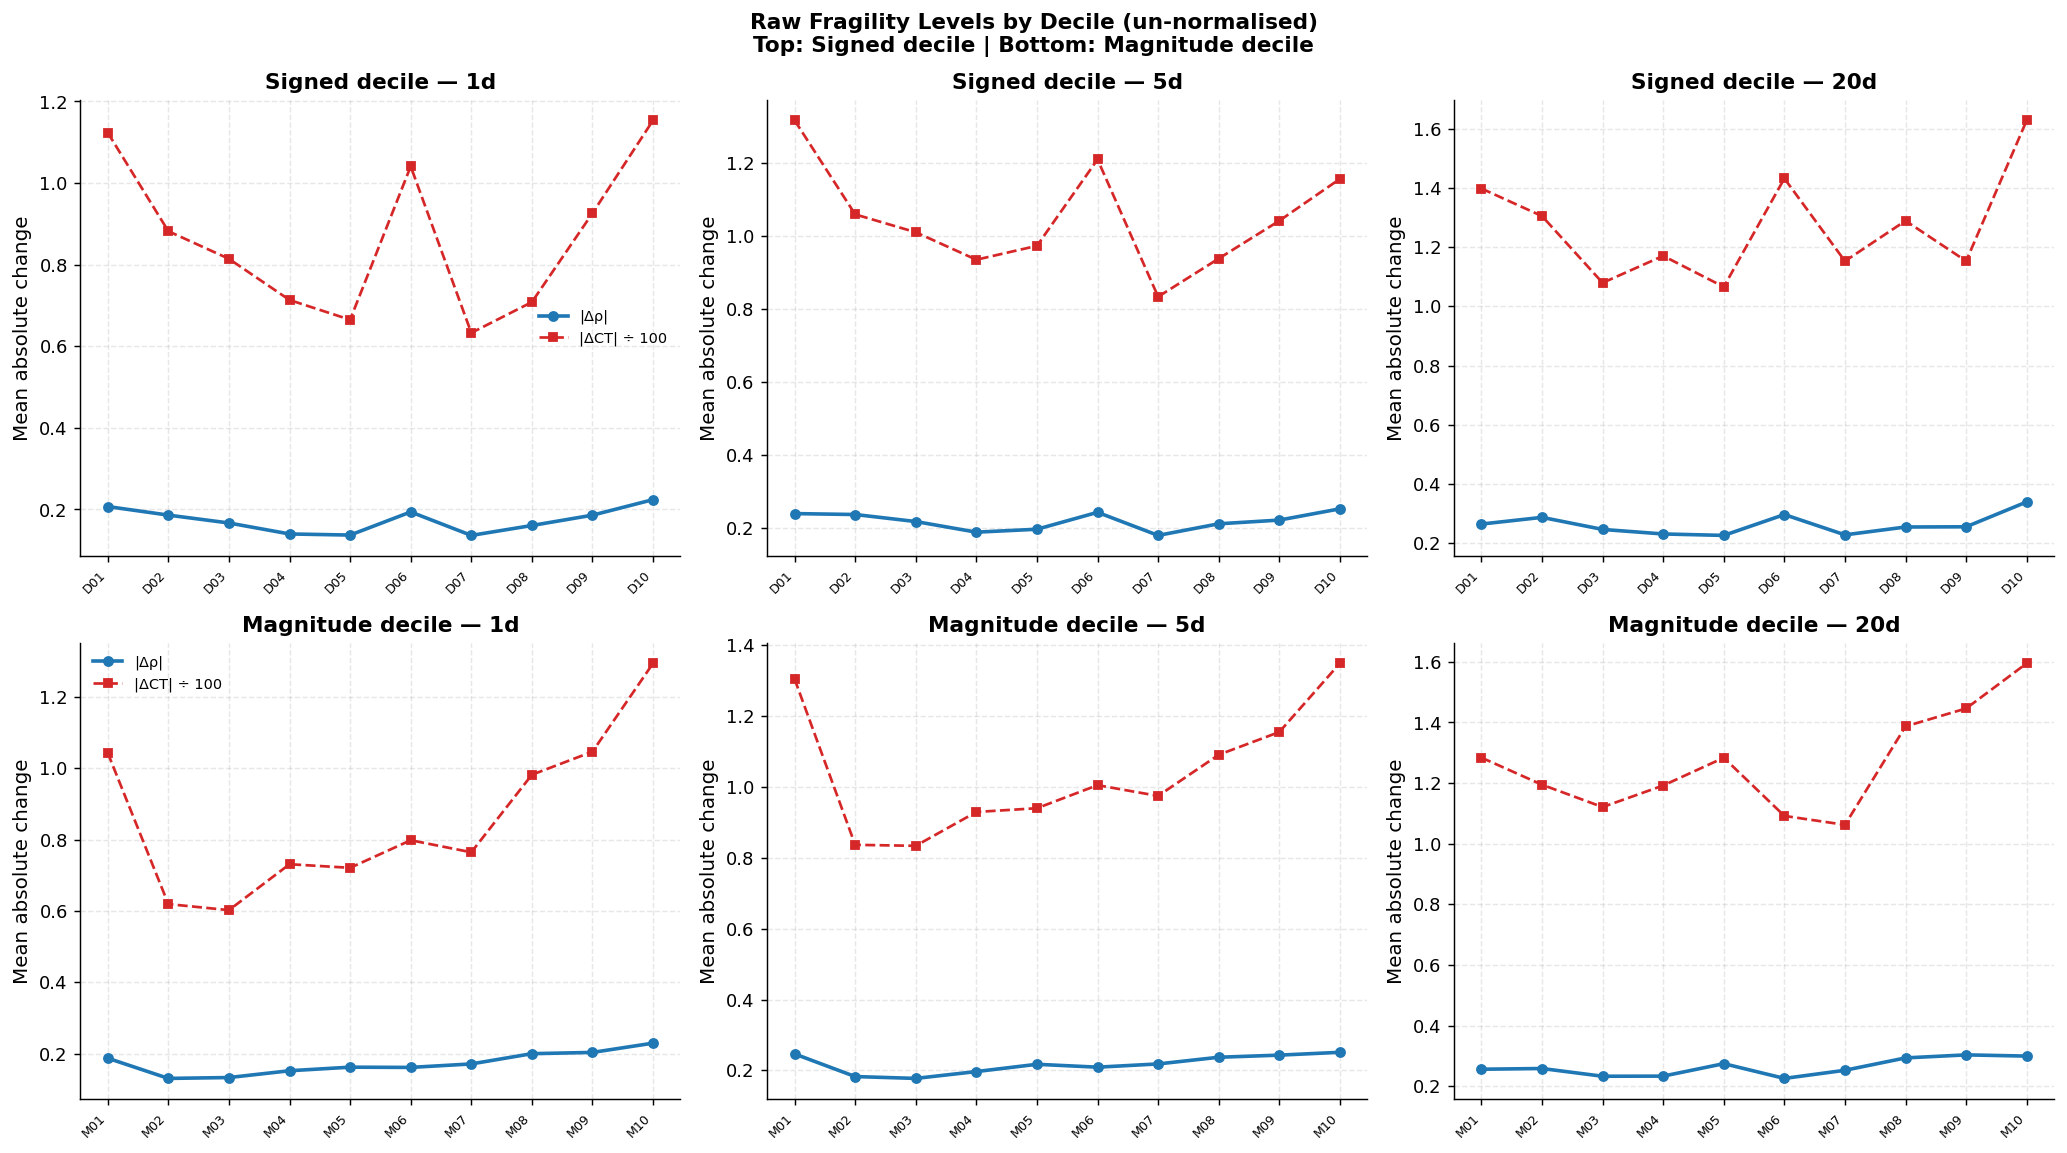

In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Raw Fragility Levels by Decile (un-normalised)\n"
             "Top: Signed decile | Bottom: Magnitude decile",
             fontweight="bold", fontsize=12)

COLORS = {"abs_rho_drift": "#1f77b4", "abs_cross_term_drift": "#d62728"}

for col_idx, h in enumerate(HORIZONS):
    # ── Row 0: signed decile ──────────────────────────────────────────────────
    ax = axes[0, col_idx]
    rho_s = grp[f"abs_rho_drift_{h}"].mean()
    ct_s  = grp[f"abs_cross_term_drift_{h}"].mean()
    x = range(len(DECILE_LABELS))
    ax.plot(x, rho_s.values, "o-",  color=COLORS["abs_rho_drift"],         lw=2,   ms=5, label="|Δρ|")
    ax.plot(x, ct_s.values / 100, "s--", color=COLORS["abs_cross_term_drift"], lw=1.5, ms=4, label="|ΔCT| ÷ 100")
    ax.set_xticks(list(x))
    ax.set_xticklabels(DECILE_LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"Signed decile — {h}", fontweight="bold")
    ax.set_ylabel("Mean absolute change")
    if col_idx == 0:
        ax.legend(frameon=False, fontsize=8)

    # ── Row 1: magnitude decile ───────────────────────────────────────────────
    ax = axes[1, col_idx]
    rho_m = mgrp[f"abs_rho_drift_{h}"].mean()
    ct_m  = mgrp[f"abs_cross_term_drift_{h}"].mean()
    xm = range(len(MAG_LABELS))
    ax.plot(xm, rho_m.values, "o-",  color=COLORS["abs_rho_drift"],         lw=2,   ms=5, label="|Δρ|")
    ax.plot(xm, ct_m.values / 100, "s--", color=COLORS["abs_cross_term_drift"], lw=1.5, ms=4, label="|ΔCT| ÷ 100")
    ax.set_xticks(list(xm))
    ax.set_xticklabels(MAG_LABELS, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"Magnitude decile — {h}", fontweight="bold")
    ax.set_ylabel("Mean absolute change")
    if col_idx == 0:
        ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

## Section 9 — Surface Relationship Sanity Check

Verify that `corr_skew_1m` is a genuine market signal, not merely an echo of equity or FX skew, or of the level of correlation itself.

- **2×2 scatter panel**: `corr_skew_1m` vs `adr_skew_1m`, `loc_skew_1m`, `fx_RR_1M`, `rho_1m`
- **Pairwise correlation matrix**: all surface and fragility columns

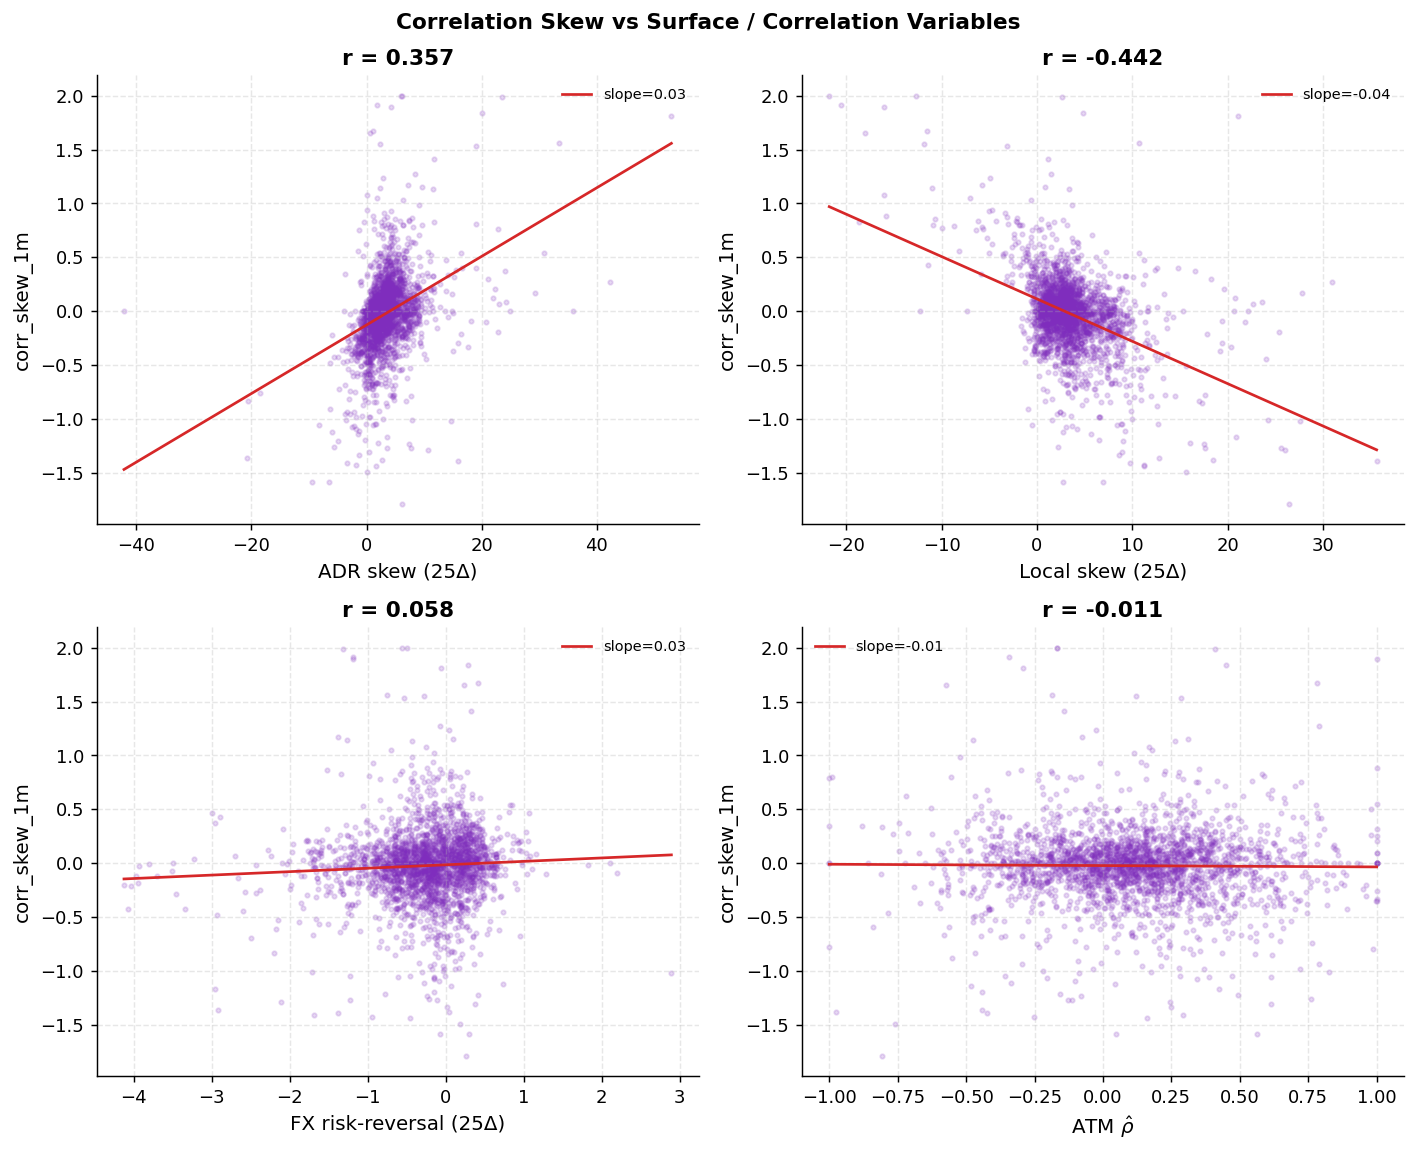

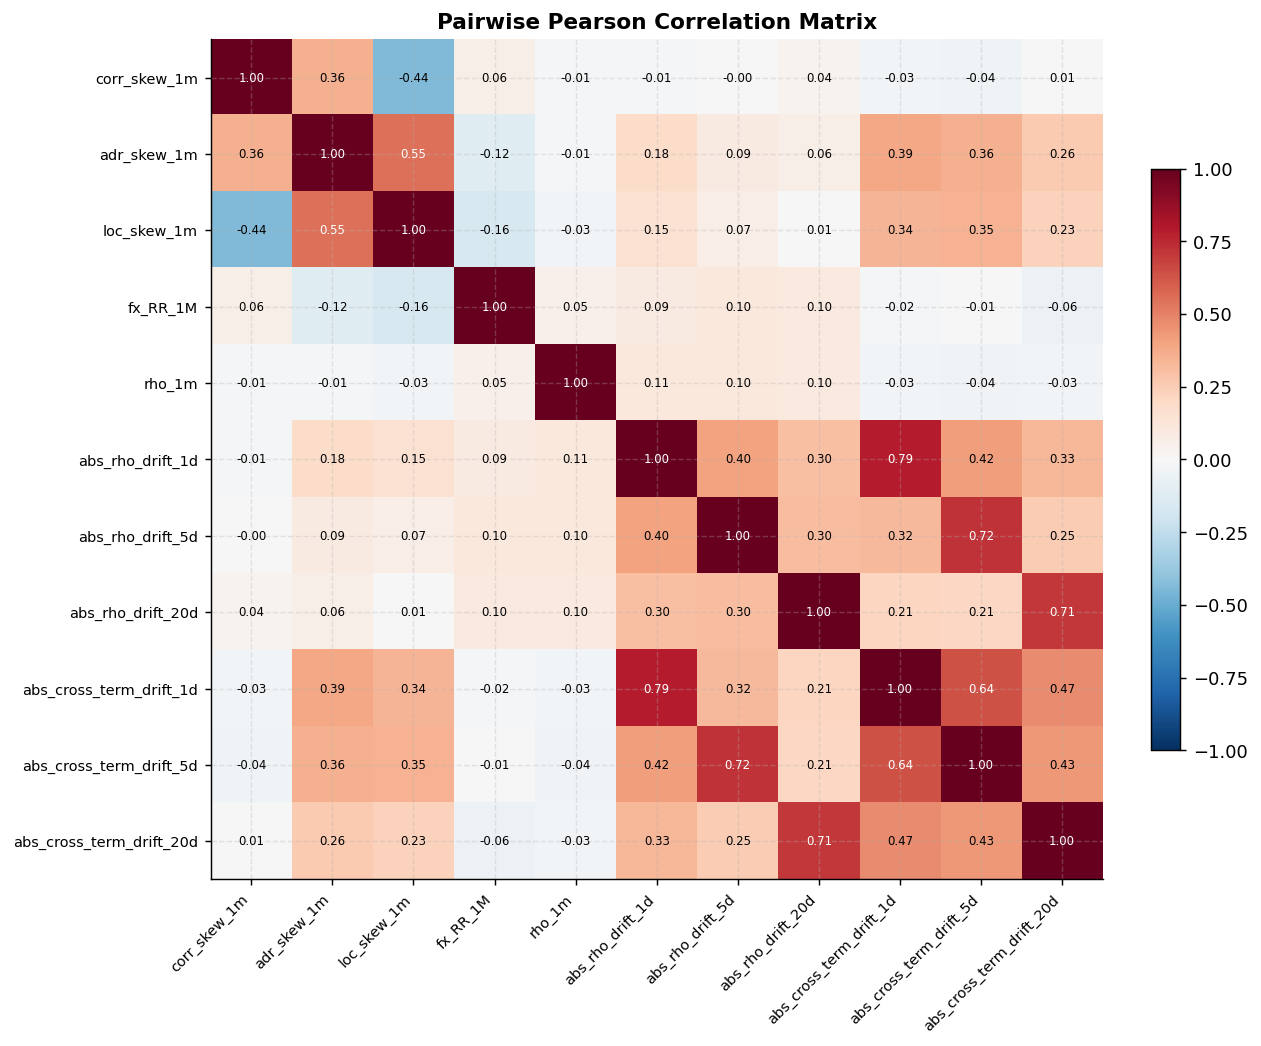

In [37]:
surface_cols = ["corr_skew_1m", "adr_skew_1m", "loc_skew_1m", "fx_RR_1M", "rho_1m"]
present = [c for c in surface_cols if c in df.columns]
missing = [c for c in surface_cols if c not in df.columns]
if missing:
    print(f"⚠️  Missing surface columns: {missing}")

pairs = [("adr_skew_1m", "ADR skew (25Δ)"),
         ("loc_skew_1m", "Local skew (25Δ)"),
         ("fx_RR_1M",    "FX risk-reversal (25Δ)"),
         ("rho_1m",      r"ATM $\hat{\rho}$")]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle("Correlation Skew vs Surface / Correlation Variables",
             fontweight="bold", fontsize=12)

for ax, (col, lbl) in zip(axes.flat, pairs):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    sub = df[["corr_skew_1m", col]].dropna()
    ax.scatter(sub[col], sub["corr_skew_1m"], alpha=0.18, s=6, color="#7f2dbd")
    # OLS trendline
    m, b = np.polyfit(sub[col], sub["corr_skew_1m"], 1)
    xfit = np.linspace(sub[col].min(), sub[col].max(), 200)
    ax.plot(xfit, m * xfit + b, color="#d62728", lw=1.5, label=f"slope={m:.2f}")
    r = np.corrcoef(sub[col], sub["corr_skew_1m"])[0, 1]
    ax.set_xlabel(lbl)
    ax.set_ylabel("corr_skew_1m")
    ax.set_title(f"r = {r:.3f}", fontweight="bold")
    ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

# ── Pairwise correlation matrix ────────────────────────────────────────────────
corr_cols = present + [f"abs_rho_drift_{h}" for h in HORIZONS] + \
                       [f"abs_cross_term_drift_{h}" for h in HORIZONS]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr().round(3)

fig2, ax2 = plt.subplots(figsize=(len(corr_cols) * 0.8 + 1, len(corr_cols) * 0.65 + 1))
im = ax2.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax2.set_xticks(range(len(corr_cols)))
ax2.set_yticks(range(len(corr_cols)))
ax2.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax2.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr_matrix.values[i, j]
        ax2.text(j, i, f"{v:.2f}", ha="center", va="center",
                 fontsize=6.5, color="white" if abs(v) > 0.5 else "black")
fig2.colorbar(im, ax=ax2, fraction=0.03)
ax2.set_title("Pairwise Pearson Correlation Matrix", fontweight="bold")
fig2.tight_layout()
plt.show()

## Section 10 — Conclusion

### Key Findings

**1. Correlation skew predicts hedge fragility nonlinearly.**  
Extreme signed deciles (D01 = most negative skew, D10 = most positive skew) exhibit materially larger future |Δρ| and |ΔCT| compared to the central decile D05. The pattern is U-shaped ("bat-shaped"), not monotone.

**2. Skew magnitude is a cleaner signal than skew sign.**  
Magnitude deciles M01–M10 show a near-monotone increase in fragility, confirming that *how extreme* the skew is matters — regardless of direction.

**3. ATM-based quanto hedges are more fragile during skew extremes.**  
The cross-term $2\hat{\rho}\,\sigma_\text{loc}\,\sigma_\text{FX}$ drifts significantly more when skew is at its tails, meaning the ATM-implied covariance that an ATM hedge locks in is less stable.

**4. Linear regression misses this relationship entirely.**  
Because the U-shape elevates *both* tails symmetrically, signed regression of `corr_skew → |Δρ|` produces $\hat{\beta} \approx 0$. The signal only manifests through nonlinear (quantile-binning) analysis.

**5. Correlation skew is not simply a proxy for equity or FX skew.**  
The 2×2 scatter (Section 9) confirms low correlations with `adr_skew_1m`, `loc_skew_1m`, and `fx_RR_1M`, establishing `corr_skew_1m` as an independent signal.

---

### Practical Implication

> A quanto hedger who monitors correlation skew can identify regimes — high |corr_skew| — where the ATM-based hedge is most likely to require active rebalancing. Standard delta-hedging frameworks that fix ρ at the ATM level will understate covariance risk during these periods.